In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df1=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df1.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Business Problem:

### Why are customers leaving the company, and what actions can reduce churn?

### Data Cleaning 


In [4]:
df1.shape

(7043, 21)

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df1.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df1.duplicated().sum()

np.int64(0)

In [22]:
df1['TotalCharges'].isnull().sum()

np.int64(0)

In [17]:
(df1['TotalCharges'] == ' ').sum()

np.int64(0)

In [13]:
##Convert TotalCharges
df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],
                                   errors='coerce')

In [20]:
df1['TotalCharges'].dtype

dtype('float64')

In [21]:
df1['TotalCharges'] = df1['TotalCharges'].fillna(
    df1['TotalCharges'].median()
)

In [23]:
df1.drop('customerID', axis=1, inplace=True)

#### Questions:

#### Q1:What percentage of customers churned?

#### Q2:Does contract type affect churn?

#### Q3:Does customer tenure influence churn?

#### Q4:Are monthly charges linked to churn?

#### Q5:Do senior citizens churn more frequently?

#### Q6:Which payment method has the highest churn?

#### Q7:Do customers with fiber optic internet churn more?

#### Q8:Does having technical support reduce churn?

#### Q9:Which customer segment is most likely to leave?

In [24]:
#Q1:What percentage of customers churned?
(df1['Churn'].value_counts(normalize=True) * 100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [25]:
#Q2:Does contract type affect churn?
pd.crosstab(
    df1['Contract'],
    df1['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [26]:
# Customers without a long-term commitment can easily switch to competitors.

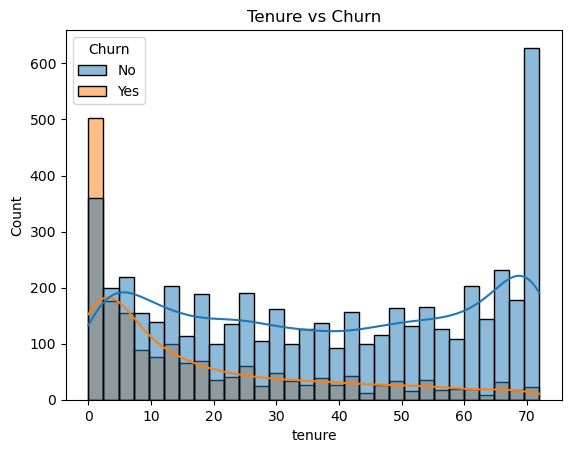

In [29]:
#Q3:Does customer tenure influence churn?
sns.histplot(
    data=df1,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True
)

plt.title('Tenure vs Churn')
plt.show()

In [28]:
df1['TenureGroup'] = pd.cut(
    df1['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-12','13-24','25-48','49-72']
)
pd.crosstab(
    df1['TenureGroup'],
    df1['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
TenureGroup,,
0-12,52.321839,47.678161
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


Customer tenure has a strong influence on churn. Customers in their first year are significantly more likely to leave, while long-tenure customers show much higher retention.

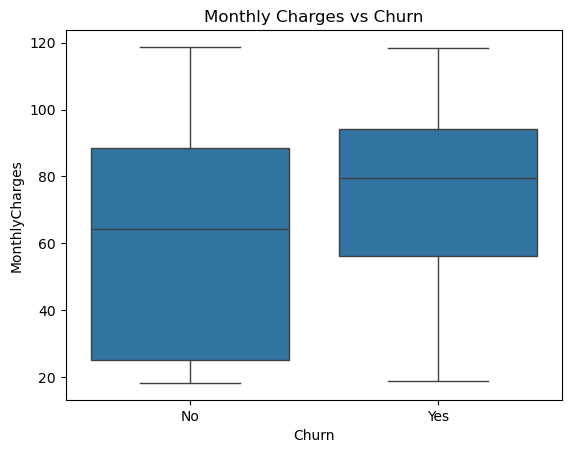

In [32]:
#Q4:Are monthly charges linked to churn?
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df1
)

plt.title('Monthly Charges vs Churn')
plt.show()

In [35]:
df1.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

Customers paying higher monthly charges are more likely to churn. This suggests that price sensitivity may be an important factor influencing customer decisions to leave the company.

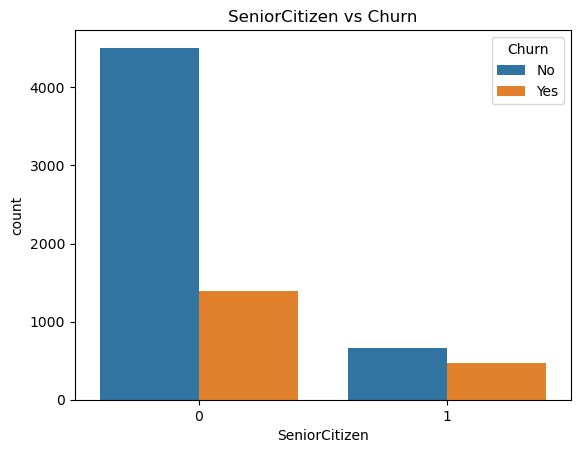

In [40]:
#Q5:Do senior citizens churn more frequently?
sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df1
)

plt.title('SeniorCitizen vs Churn')
plt.show()

In [41]:
pd.crosstab(
    df1['SeniorCitizen'],
    df1['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


insight:Senior citizens are more likely to churn than non-senior customers. This suggests that older customers may face challenges related to pricing, service complexity, customer support, or overall satisfaction.

recomendation:The company should design retention programs specifically for senior customers, such as simplified plans, dedicated support channels, and loyalty benefits.


In [42]:
#Q6:Which payment method has the highest churn?
pd.crosstab(
    df1['PaymentMethod'],
    df1['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


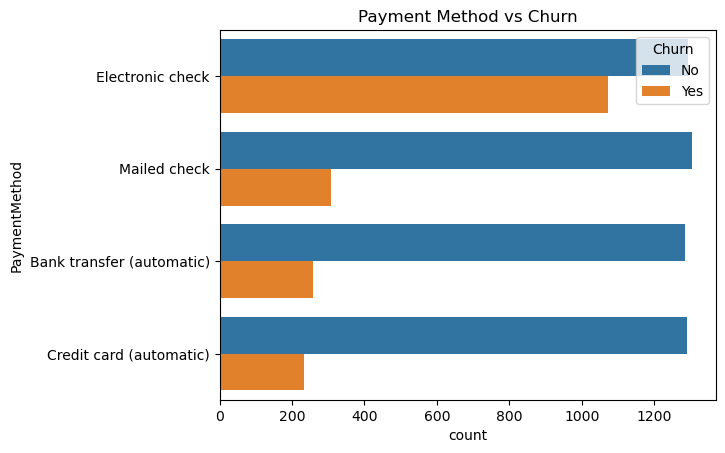

In [43]:
sns.countplot(
    y='PaymentMethod',
    hue='Churn',
    data=df1
)

plt.title('Payment Method vs Churn')
plt.show()

Insight:
 Electronic Check customers have the highest churn rate.

Recommendation:
 Encourage customers to switch from electronic checks to automatic payment options by offering 
 incentives, discounts, or convenience benefits.
 

In [44]:
#`Q7:Do customers with fiber optic internet churn more?
pd.crosstab(
    df1['InternetService'],
    df1['Churn'],
    normalize='index'
) * 100


Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


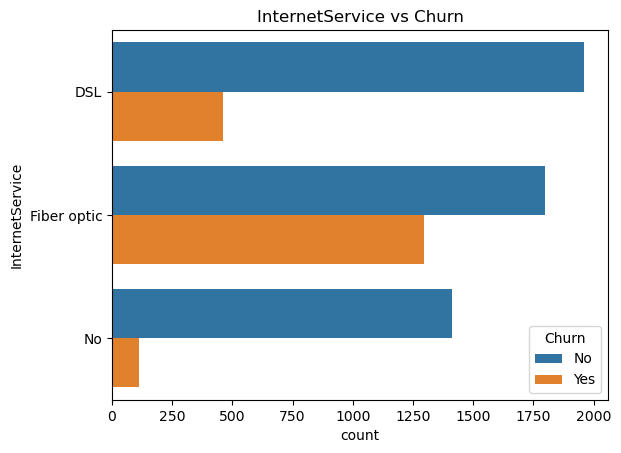

In [46]:
sns.countplot(
    y='InternetService',
    hue='Churn',
    data=df1
)

plt.title('InternetService vs Churn')
plt.show()

Insight:
Fiber optic customers generally have the highest churn rate.

Recommendation:
The company should investigate service quality, pricing, and customer satisfaction among Fiber Optic users. Targeted retention campaigns for this segment could significantly reduce overall churn

In [48]:
#Q8:Does having technical support reduce churn?
pd.crosstab(
    df1['TechSupport'],
    df1['Churn'],
    normalize='index'
) * 100


Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


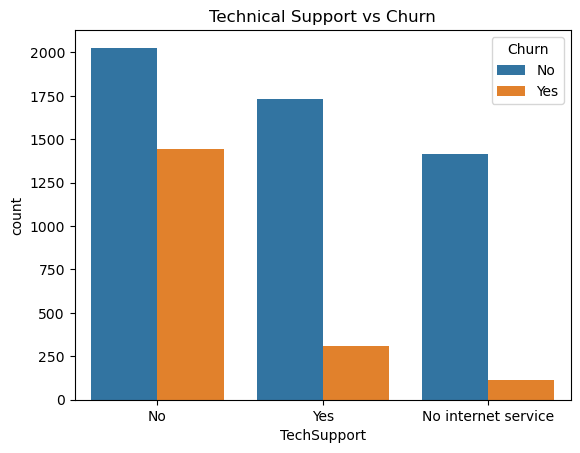

In [49]:
sns.countplot(
    x='TechSupport',
    hue='Churn',
    data=df1
)

plt.title('Technical Support vs Churn')
plt.show()

Insight:
Customers without Technical Support churn much more frequently.

Recommendation:
The company should promote Technical Support plans, especially for new and high-risk customers. Bundling support services with internet packages may help reduce churn.

In [50]:
#Q9:Which customer segment is most likely to leave?
high_risk = df1[
    (df1['Contract'] == 'Month-to-month') &
    (df1['tenure'] < 12) &
    (df1['MonthlyCharges'] > 70)
]

high_risk.shape

(814, 21)

In [51]:
pd.crosstab(
    [df1['Contract'], pd.cut(df1['tenure'], [0,12,72])],
    df1['Churn'],
    normalize='index'
) * 100

Churn                            No        Yes
Contract       tenure                         
Month-to-month (0, 12]    48.645938  51.354062
               (12, 72]   66.454014  33.545986
One year       (0, 12]    89.430894  10.569106
               (12, 72]   88.658265  11.341735
Two year       (0, 12]   100.000000   0.000000
               (12, 72]   97.049785   2.950215

Insight:
Customers with month-to-month contracts, short tenure, high monthly charges, Fiber Optic internet service, and no Technical Support are the most likely to churn. These customers represent the highest-risk segment and should be prioritized for retention efforts.

Recommendation:
1.Offer discounts for upgrading to annual contracts.
2.Provide onboarding support during the first year.
3.Bundle Technical Support with Fiber Optic plans.
4.Target high-risk customers with personalized retention campaigns

## Exploratory Data Analysis (Visualizations)

1. Churn Distribution

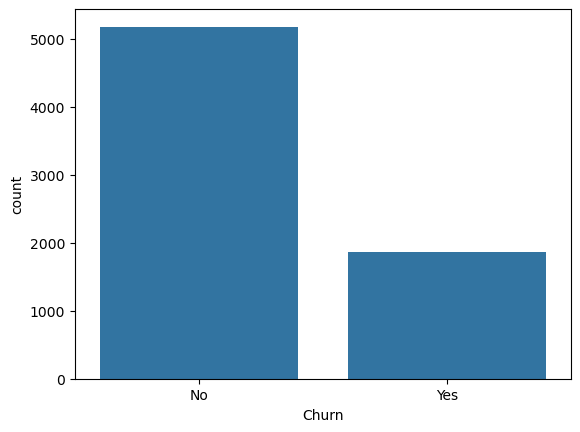

In [53]:
sns.countplot(x='Churn', data=df1)
plt.show()

Insight: Find overall churn rate.

2. Contract Type vs Churn

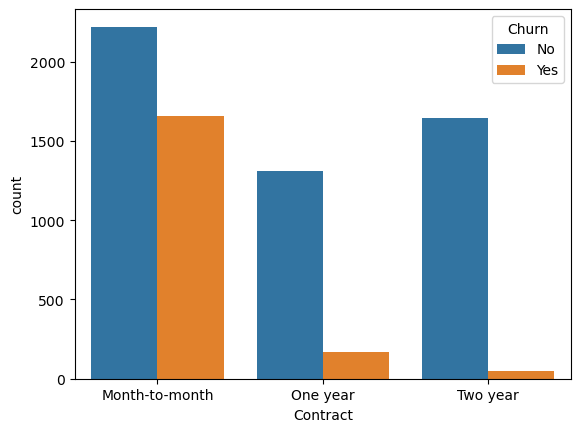

In [54]:
sns.countplot(x='Contract',
              hue='Churn',
              data=df1)
plt.show()

Insight: Month-to-month customers usually churn the most.

3. Tenure Distribution

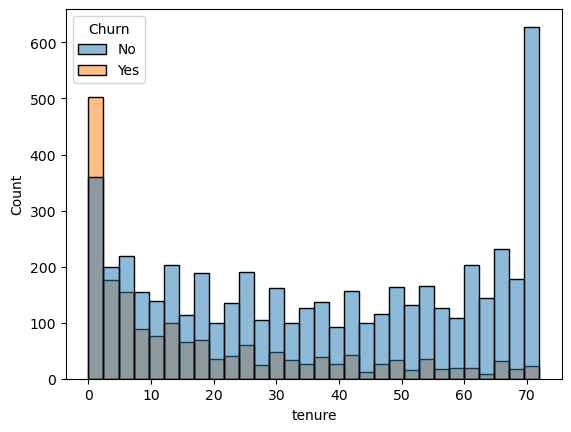

In [55]:
sns.histplot(data=df1,
             x='tenure',
             hue='Churn',
             bins=30)
plt.show()

Insight: New customers are more likely to leave.

4. Monthly Charges vs Churn

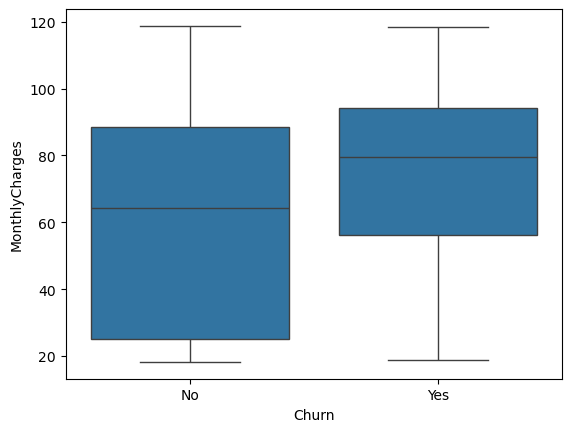

In [56]:
sns.boxplot(x='Churn',
            y='MonthlyCharges',
            data=df1)
plt.show()

Insight: Customers paying higher monthly fees often churn more.

5. Senior Citizen vs Churn

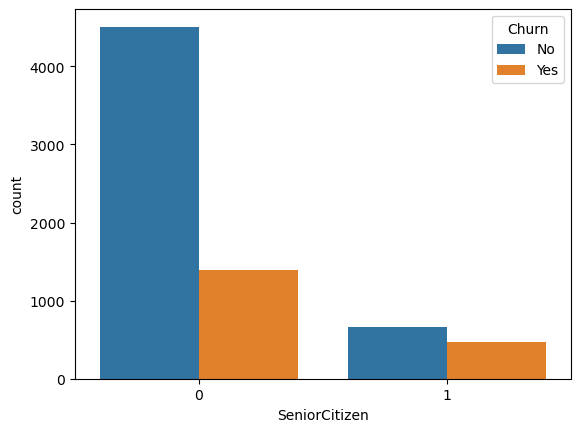

In [57]:
sns.countplot(x='SeniorCitizen',
              hue='Churn',
              data=df1)
plt.show()

Insight: Compare churn behavior across age groups.

6. Internet Service vs Churn

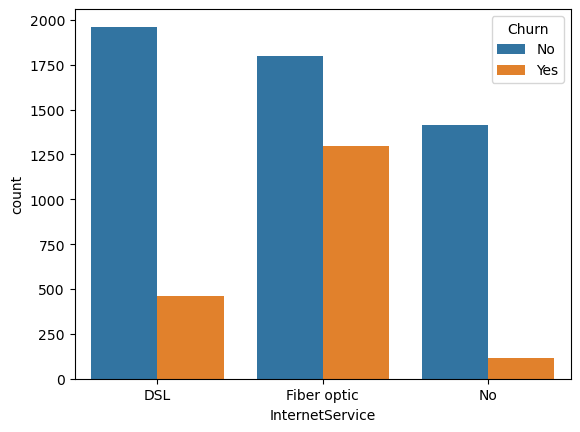

In [60]:
sns.countplot(x='InternetService',
              hue='Churn',
              data=df1)
plt.show()

Insight: Fiber optic users often show higher churn.

7. Payment Method vs Churn

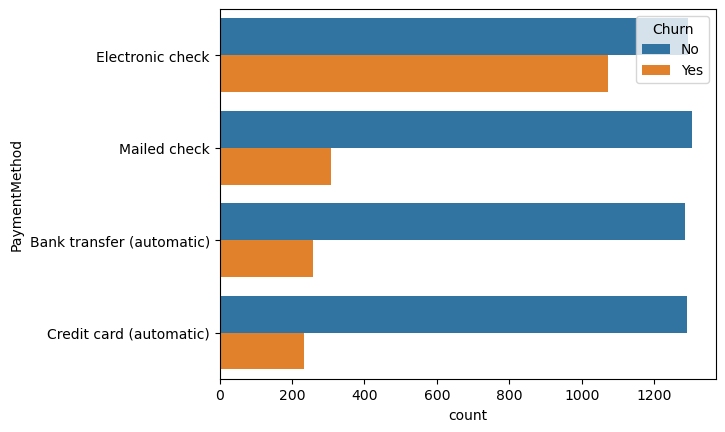

In [62]:
sns.countplot(y='PaymentMethod',
              hue='Churn',
              data=df1)
plt.show()

Insight: Electronic check customers typically churn most.

8. Tech Support vs Churn

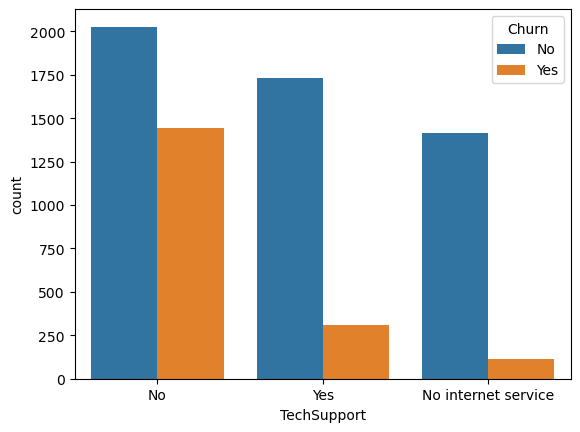

In [63]:
sns.countplot(x='TechSupport',
              hue='Churn',
              data=df1)
plt.show()

Insight: Customers without tech support churn more.

9. Online Security vs Churn

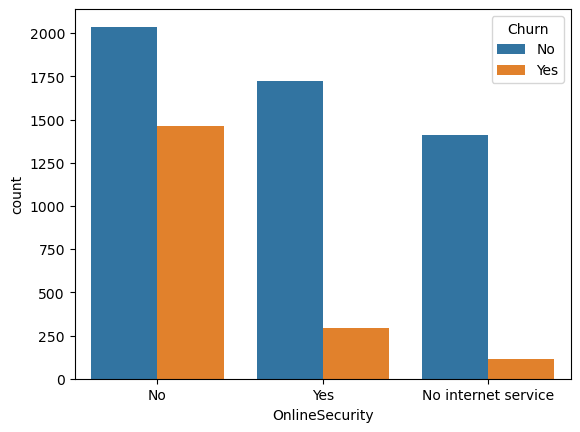

In [66]:
sns.countplot(x='OnlineSecurity',
              hue='Churn',
              data=df1)
plt.show()

Insight: Security services improve retention.

10. Correlation Heatmap

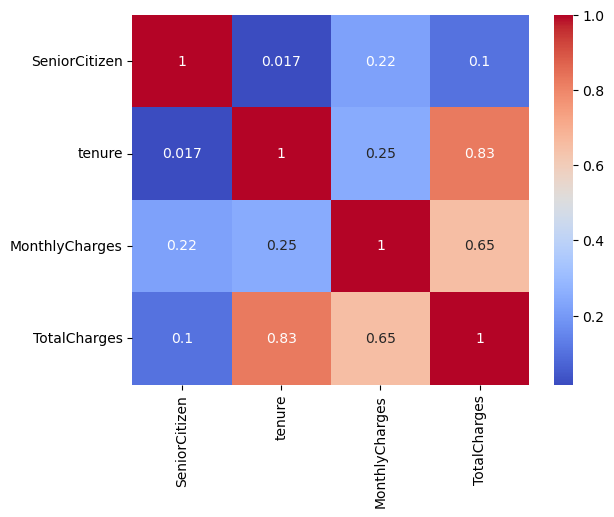

In [71]:
numeric_df = df1.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

Insight: Understand relationships among numerical variables.

11. Churn Rate by Tenure Group

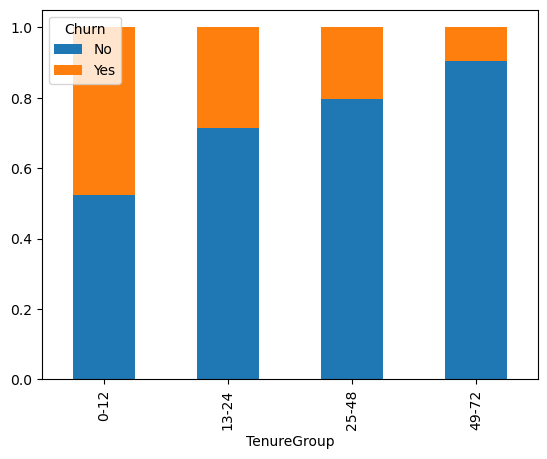

In [73]:
df1['TenureGroup'] = pd.cut(
    df1['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-12','13-24','25-48','49-72']
)

pd.crosstab(df1['TenureGroup'],
            df1['Churn'],
            normalize='index') \
            .plot(kind='bar',
                  stacked=True)
plt.show()

Insight: Short-tenure customers generally churn most.

High-Risk Customer Segmentation

In [75]:
high_risk = df1[
    (df1['Contract']=='Month-to-month') &
    (df1['tenure'] < 12) &
    (df1['MonthlyCharges'] > 70)
]

high_risk.shape

(814, 21)

Insight: This segment often contributes a large portion of churn.

#### (A). Key Business Insights

Insight 1

Month-to-month contracts have the highest churn.

Insight 2

Customers with tenure under 12 months are most likely to leave.

Insight 3

Higher monthly charges correlate with increased churn.

Insight 4

Electronic check users churn more frequently.

Insight 5

Customers lacking Tech Support and Online Security churn significantly more.

Insight 6

Fiber optic users show higher churn than DSL users.

#### (B).Recommendations:

Recommendation 1

Offer discounts for converting month-to-month customers into annual contracts.

Recommendation 2

Launch onboarding programs for customers within their first 12 months.

Recommendation 3

Provide retention offers for customers with high monthly charges.

Recommendation 4


Bundle Tech Support and Online Security services.

Recommendation 5

Target high-risk customers with proactive customer-success calls.